## 📝 Instrucciones

**Prediciendo la diabetes**

En los dos proyectos anteriores vimos cómo podíamos utilizar un árbol de decisión y después un random forest para mejorar la predicción de la diabetes. Hemos llegado a un punto en el que necesitamos mejorar. ¿Puede ser boosting la mejor de las alternativas para optimizar los resultados?

Boosting es una composición de modelos (generalmente árboles de decisión) secuencial en la cual el modelo nuevo persigue corregir los errores del anterior. Puede que esta visión nos sea útil en este conjunto de datos, ya que se cumplen varias de las suposiciones estudiadas en el módulo.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el accuracy.

## Paso 1: Carga del conjunto de datos

Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, RepeatedKFold, RepeatedKFold
import multiprocessing

In [2]:
X_train = pd.read_csv("../data/processed/diabetes/X_train.csv")
y_train = pd.read_csv("../data/processed/diabetes/y_train.csv")
X_test = pd.read_csv("../data/processed/diabetes/X_test.csv")
y_test = pd.read_csv("../data/processed/diabetes/y_test.csv")

In [3]:
X_train.shape
X_test.shape

(154, 8)

## Paso 2: Construye un boosting

Una forma de optimizar y mejorar los resultados es generar un boosting de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los hiperparámetros que definen al modelo con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

In [4]:
#Modelo
model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train.values.ravel())

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [5]:
#Preddiciones
preds = model.predict(X = X_test)
print(preds)

[1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]


In [6]:
#Métricas
accuracy = accuracy_score(y_test, preds)
con_matrix = confusion_matrix(y_test, preds)
classification_report = classification_report(y_test, preds)
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix: \n{con_matrix}")
print(f"Classification Report: \n{classification_report}")

Accuracy: 0.7532467532467533
Confusion Matrix: 
[[83 17]
 [21 33]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



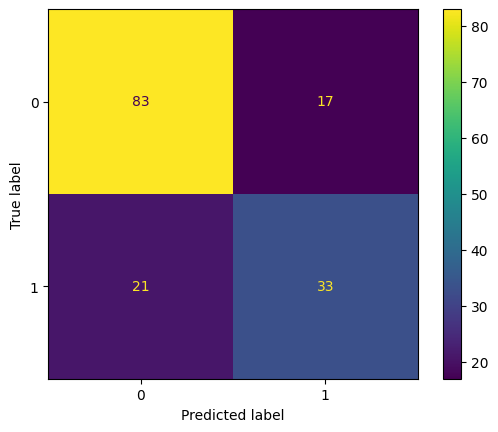

In [14]:
con_matrix_display = ConfusionMatrixDisplay(confusion_matrix=con_matrix)
con_matrix_display.plot()

**El modelo de boosting presenta un accuracy de 75%, muy similar al Random Forest (76%), pero con un comportamiento más equilibrado entre clases. El recall de 0.61 es la mejora más destacable respecto a los otros modelos, sin embargo, 21 casos positivos (falsos negativos) es una cifra muy alta considerando que el análisis es un estudio médico y tener una tasa de 39% de casos detectados como negativo de diabetes siendo que sí lo tienen, es muy peligroso. Por tanto intentemos optimizar el modelo para mejorar el recall de la clase 1.**

In [7]:
#Definimos los hiperparámetros a evaluar
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'l2_regularization': [0, 1, 10],
    'max_iter': [100, 200, 300]
}

In [8]:
#Búsqueda Grid Search con validación cruzada
grid = GridSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedKFold(n_splits=3, n_repeats=1, random_state=42),
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid.fit(X_train, y_train.values.ravel())
    

Fitting 3 folds for each of 81 candidates, totalling 243 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'l2_regularization': [0, 1, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'max_iter': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedKFold...ndom_state=42)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [9]:
#Resultados:
print(f"Mejores hiperparámetros: {grid.best_params_}")
print(f"Mejor recall: {grid.best_score_}")

Mejores hiperparámetros: {'l2_regularization': 0, 'learning_rate': 0.01, 'max_depth': 7, 'max_iter': 300}
Mejor recall: 0.6168609168609169


In [10]:
mejor_modelo = grid.best_estimator_
preds_mejor_modelo = mejor_modelo.predict(X_test)

In [13]:
classification_report_mejor_modelo = classification_report(y_test, preds_mejor_modelo)
print(f"Classification Report del mejor modelo: \n{classification_report_mejor_modelo}")

TypeError: 'str' object is not callable

In [ ]:
accuracy_mejor_modelo = accuracy_score(y_test, preds_mejor_modelo)
con_matrix_mejor_modelo = confusion_matrix(y_test, preds_mejor_modelo)
classification_report_mejor_modelo = classification_report(y_test, preds_mejor_modelo)
print(f"Accuracy del mejor modelo: {accuracy_mejor_modelo}")
print(f"Confusion Matrix del mejor modelo: \n{con_matrix_mejor_modelo}")
print(f"Classification Report del mejor modelo: \n{classification_report_mejor_modelo}")


## Paso 3: Guarda el modelo

Almacena el modelo en la carpeta correspondiente.

## Paso 4: Analiza y compara los resultados de los modelos

Haz un estudio ahora de los tres modelos utilizados, analiza sus predicciones, la clase con más precisión de predicción y la que menos. ¿Con cuál de los tres modelos te quedas?